# Notebook 08 — PCA and Clustering

## Objective

This notebook applies unsupervised Data Mining techniques to the selected
respiratory-sound features.

The objectives are to:

1. Standardize the selected audio features.
2. Apply Principal Component Analysis (PCA).
3. Analyze explained variance.
4. Visualize the respiratory-cycle feature space.
5. Identify natural groups using K-Means clustering.
6. Determine a suitable number of clusters.
7. Evaluate cluster quality using the Silhouette Score.
8. Apply hierarchical clustering as a second clustering approach.
9. Compare discovered clusters with disease and respiratory-sound labels
   as post-hoc analysis.

## Important Methodological Principle

Disease labels and respiratory sound labels are NOT used to create the
clusters.

Clustering is performed using only the selected audio features.

Labels are introduced afterward only to interpret and evaluate the
resulting clusters.

## Leakage Prevention

The feature scaler and PCA transformation are fitted using the training
data only.

The official test data is transformed using the already-fitted training
transformer and is not used to fit PCA or determine the clustering
parameters.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import (
    silhouette_score,
    adjusted_rand_score,
    normalized_mutual_info_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DATA_DIR = (
    PROJECT_ROOT / "data" / "processed"
)

FEATURES_DIR = (
    PROCESSED_DATA_DIR / "features"
)

FEATURE_SELECTION_DIR = (
    PROCESSED_DATA_DIR / "feature_selection"
)

ANALYSIS_DIR = (
    PROCESSED_DATA_DIR / "analysis"
)

print("Project root:", PROJECT_ROOT)

Project root: /Users/vs/Sem 5/Respiratory-Disease-Classification


In [3]:
features_df = pd.read_csv(
    FEATURES_DIR /
    "respiratory_cycle_features.csv"
)

print("Feature dataset shape:", features_df.shape)

Feature dataset shape: (6898, 52)


In [4]:
selected_features_df = pd.read_csv(
    FEATURE_SELECTION_DIR /
    "selected_features.csv"
)

selected_features = (
    selected_features_df["feature"]
    .tolist()
)

print(
    "Number of selected features:",
    len(selected_features)
)

print("\nSelected features:")

for i, feature in enumerate(selected_features, 1):
    print(f"{i:02d}. {feature}")

Number of selected features: 33

Selected features:
01. spectral_entropy
02. mfcc_11_mean
03. zero_crossing_rate
04. dominant_frequency
05. mfcc_13_mean
06. wavelet_entropy
07. mfcc_1_mean
08. spectral_bandwidth
09. spectral_rolloff
10. mfcc_5_mean
11. mfcc_3_mean
12. mfcc_8_mean
13. peak_to_peak
14. mfcc_9_mean
15. mfcc_12_mean
16. mfcc_7_mean
17. mfcc_2_mean
18. energy
19. rms
20. mfcc_6_mean
21. band_energy_500_1000
22. spectral_flatness
23. band_energy_0_500
24. mfcc_4_mean
25. band_energy_1000_1500
26. min
27. mfcc_10_mean
28. skewness
29. mean
30. kurtosis
31. median
32. band_energy_1500_2000
33. max


In [5]:
recordings_df = pd.read_csv(
    PROJECT_ROOT /
    "data" /
    "interim" /
    "recordings.csv"
)

print("Recordings shape:", recordings_df.shape)

Recordings shape: (920, 7)


In [6]:
split_columns = [
    "patient_id",
    "recording_id",
    "chest_location",
    "official_split"
]

features_with_split = features_df.merge(
    recordings_df[split_columns],
    on=[
        "patient_id",
        "recording_id",
        "chest_location"
    ],
    how="left",
    validate="many_to_one"
)

print(
    "Features with split shape:",
    features_with_split.shape
)

print(
    "Missing split values:",
    features_with_split[
        "official_split"
    ].isna().sum()
)

Features with split shape: (6898, 53)
Missing split values: 0


In [7]:
train_df = features_with_split[
    features_with_split["official_split"] == "train"
].copy()

test_df = features_with_split[
    features_with_split["official_split"] == "test"
].copy()

print("Training cycles:", len(train_df))
print("Testing cycles:", len(test_df))

Training cycles: 4142
Testing cycles: 2756


In [8]:
X_train = train_df[
    selected_features
].copy()

X_test = test_df[
    selected_features
].copy()

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (4142, 33)
X_test: (2756, 33)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Training scaled shape:", X_train_scaled.shape)
print("Testing scaled shape:", X_test_scaled.shape)

Training scaled shape: (4142, 33)
Testing scaled shape: (2756, 33)


In [10]:
pca_full = PCA()

X_train_pca_full = pca_full.fit_transform(
    X_train_scaled
)

X_test_pca_full = pca_full.transform(
    X_test_scaled
)

print(
    "Number of PCA components:",
    pca_full.n_components_
)

Number of PCA components: 33


In [11]:
explained_variance_df = pd.DataFrame({
    "component": np.arange(
        1,
        len(pca_full.explained_variance_ratio_) + 1
    ),
    "explained_variance_ratio":
        pca_full.explained_variance_ratio_,
})

explained_variance_df[
    "cumulative_explained_variance"
] = (
    explained_variance_df[
        "explained_variance_ratio"
    ].cumsum()
)

display(explained_variance_df)

,component,explained_variance_ratio,cumulative_explained_variance
0,1,2.794182e-01,0.279418
1,2,9.681968e-02,0.376238
2,3,7.718916e-02,0.453427
3,4,6.816792e-02,0.521595
4,5,6.145328e-02,0.583048
5,6,5.793107e-02,0.640979
6,7,4.940954e-02,0.690389
7,8,4.248005e-02,0.732869
8,9,3.209365e-02,0.764963
9,10,2.590000e-02,0.790863


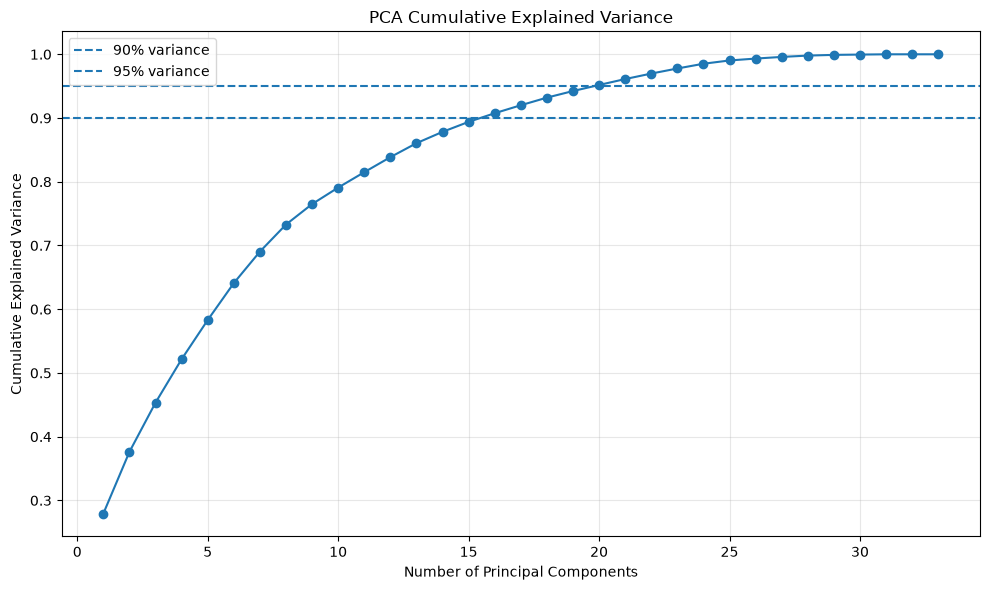

In [14]:
plt.figure(figsize=(10, 6))

plt.plot(
    explained_variance_df["component"],
    explained_variance_df[
        "cumulative_explained_variance"
    ],
    marker="o"
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% variance"
)

plt.axhline(
    0.95,
    linestyle="--",
    label="95% variance"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title(
    "PCA Cumulative Explained Variance"
)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
components_90 = (
    np.argmax(
        explained_variance_df[
            "cumulative_explained_variance"
        ].values >= 0.90
    ) + 1
)

components_95 = (
    np.argmax(
        explained_variance_df[
            "cumulative_explained_variance"
        ].values >= 0.95
    ) + 1
)

print(
    "Components required for 90% variance:",
    components_90
)

print(
    "Components required for 95% variance:",
    components_95
)

Components required for 90% variance: 16
Components required for 95% variance: 20


In [16]:
pca_2d = PCA(
    n_components=2
)

X_train_pca_2d = pca_2d.fit_transform(
    X_train_scaled
)

X_test_pca_2d = pca_2d.transform(
    X_test_scaled
)

print(
    "PC1 variance:",
    pca_2d.explained_variance_ratio_[0]
)

print(
    "PC2 variance:",
    pca_2d.explained_variance_ratio_[1]
)

print(
    "Total 2D explained variance:",
    pca_2d.explained_variance_ratio_.sum()
)

PC1 variance: 0.2794181721482256
PC2 variance: 0.09681967837916186
Total 2D explained variance: 0.37623785052738745


In [17]:
pca_train_df = pd.DataFrame({
    "PC1": X_train_pca_2d[:, 0],
    "PC2": X_train_pca_2d[:, 1],
    "diagnosis": train_df["diagnosis"].values,
    "sound_label": train_df["sound_label"].values
})

display(pca_train_df.head())

,PC1,PC2,diagnosis,sound_label
0,-2.772345,-1.796850,Asthma,Wheezes
1,-3.535289,-2.893036,Asthma,Normal
2,-3.383417,-2.307130,Asthma,Wheezes
3,-3.324297,-2.685109,Asthma,Wheezes
4,-3.033841,-1.830712,Asthma,Wheezes


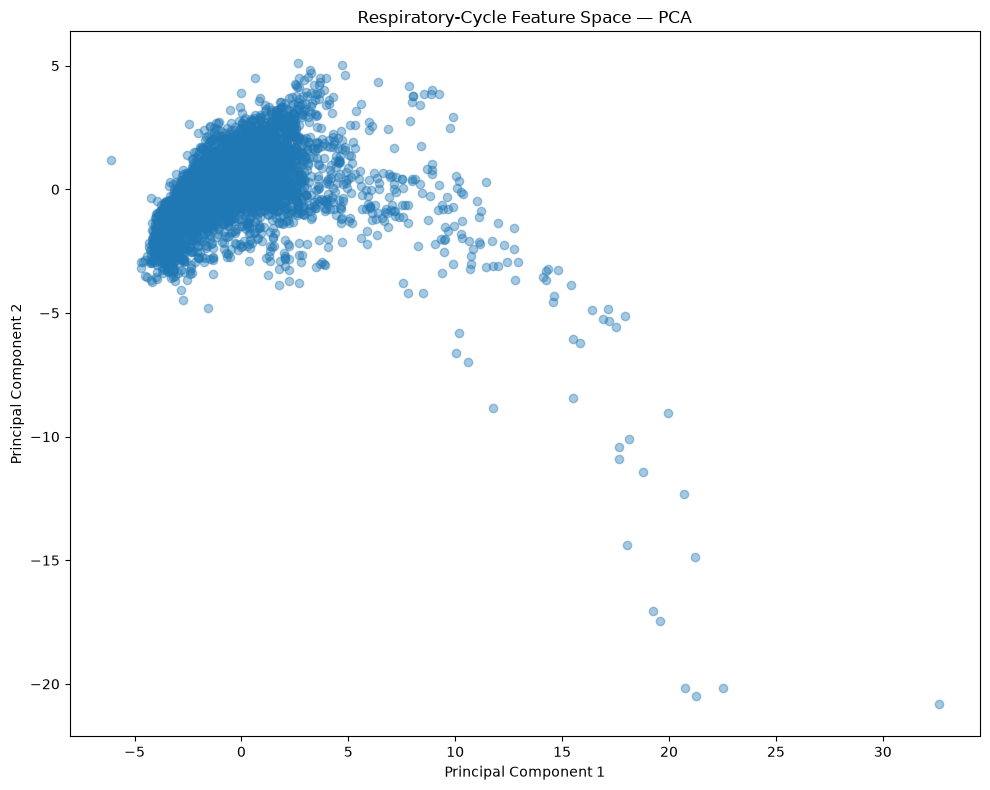

In [18]:
plt.figure(figsize=(10, 8))

plt.scatter(
    pca_train_df["PC1"],
    pca_train_df["PC2"],
    alpha=0.4
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "Respiratory-Cycle Feature Space — PCA"
)

plt.tight_layout()
plt.show()

In [19]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    cluster_labels = kmeans.fit_predict(
        X_train_scaled
    )

    inertias.append(
        kmeans.inertia_
    )

    silhouette_scores.append(
        silhouette_score(
            X_train_scaled,
            cluster_labels
        )
    )

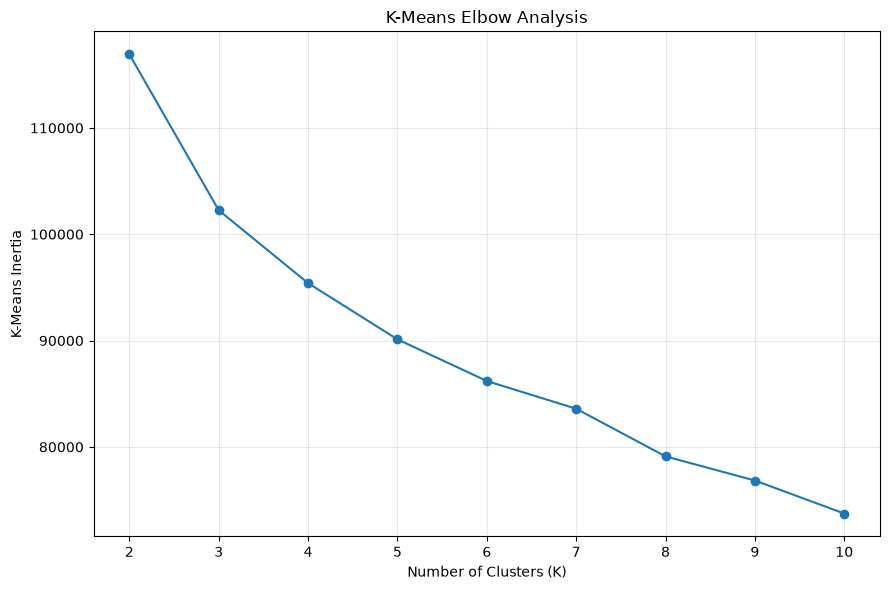

In [20]:
plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("K-Means Inertia")
plt.title(
    "K-Means Elbow Analysis"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

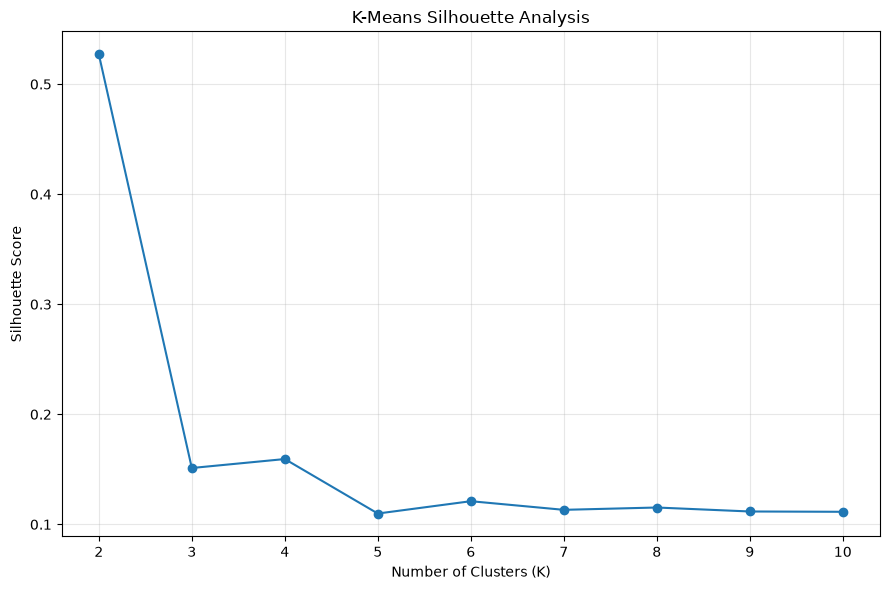

In [21]:
plt.figure(figsize=(9, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title(
    "K-Means Silhouette Analysis"
)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [23]:
# ============================================================
# Recreate K-Means Analysis Table
# ============================================================

silhouette_df = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertias,
    "silhouette_score": silhouette_scores
})

display(silhouette_df)

,k,inertia,silhouette_score
0,2,116925.653796,0.527122
1,3,102257.228364,0.151209
2,4,95400.645595,0.159349
3,5,90115.861068,0.109837
4,6,86195.110559,0.121041
5,7,83588.644346,0.113197
6,8,79105.535346,0.115308
7,9,76836.350807,0.111699
8,10,73730.942298,0.111418


In [24]:
# ============================================================
# Save PCA and Clustering Analysis
# ============================================================

PCA_DIR = (
    PROCESSED_DATA_DIR /
    "pca_clustering"
)

PCA_DIR.mkdir(
    parents=True,
    exist_ok=True
)

explained_variance_df.to_csv(
    PCA_DIR /
    "pca_explained_variance.csv",
    index=False
)

silhouette_df.to_csv(
    PCA_DIR /
    "kmeans_cluster_analysis.csv",
    index=False
)

print("PCA and clustering analysis tables saved.")
print("Output directory:")
print(PCA_DIR)

PCA and clustering analysis tables saved.
Output directory:
/Users/vs/Sem 5/Respiratory-Disease-Classification/data/processed/pca_clustering


In [25]:
print("Components for 90%:", components_90)
print("Components for 95%:", components_95)

display(silhouette_df)

Components for 90%: 16
Components for 95%: 20


,k,inertia,silhouette_score
0,2,116925.653796,0.527122
1,3,102257.228364,0.151209
2,4,95400.645595,0.159349
3,5,90115.861068,0.109837
4,6,86195.110559,0.121041
5,7,83588.644346,0.113197
6,8,79105.535346,0.115308
7,9,76836.350807,0.111699
8,10,73730.942298,0.111418


In [26]:
# ============================================================
# Final K-Means Clustering
# ============================================================

optimal_k = 2

kmeans_final = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

train_clusters = kmeans_final.fit_predict(
    X_train_scaled
)

test_clusters = kmeans_final.predict(
    X_test_scaled
)

print("Selected K:", optimal_k)

print("\nTraining cluster distribution:")
print(
    pd.Series(train_clusters)
    .value_counts()
    .sort_index()
)

print("\nTesting cluster distribution:")
print(
    pd.Series(test_clusters)
    .value_counts()
    .sort_index()
)

Selected K: 2

Training cluster distribution:
0    3966
1     176
Name: count, dtype: int64

Testing cluster distribution:
0    2695
1      61
Name: count, dtype: int64


In [27]:
train_clustered_df = train_df.copy()
test_clustered_df = test_df.copy()

train_clustered_df["cluster"] = train_clusters
test_clustered_df["cluster"] = test_clusters

print("Training clustered data:")
display(
    train_clustered_df[
        [
            "patient_id",
            "recording_id",
            "diagnosis",
            "sound_label",
            "cluster"
        ]
    ].head()
)

Training clustered data:


,patient_id,recording_id,diagnosis,sound_label,cluster
36,103,2b2,Asthma,Wheezes,0
37,103,2b2,Asthma,Normal,0
38,103,2b2,Asthma,Wheezes,0
39,103,2b2,Asthma,Wheezes,0
40,103,2b2,Asthma,Wheezes,0


In [28]:
pca_cluster_df = pd.DataFrame({
    "PC1": X_train_pca_2d[:, 0],
    "PC2": X_train_pca_2d[:, 1],
    "cluster": train_clusters,
    "diagnosis": train_df["diagnosis"].values,
    "sound_label": train_df["sound_label"].values
})

display(pca_cluster_df.head())

,PC1,PC2,cluster,diagnosis,sound_label
0,-2.772345,-1.796850,0,Asthma,Wheezes
1,-3.535289,-2.893036,0,Asthma,Normal
2,-3.383417,-2.307130,0,Asthma,Wheezes
3,-3.324297,-2.685109,0,Asthma,Wheezes
4,-3.033841,-1.830712,0,Asthma,Wheezes


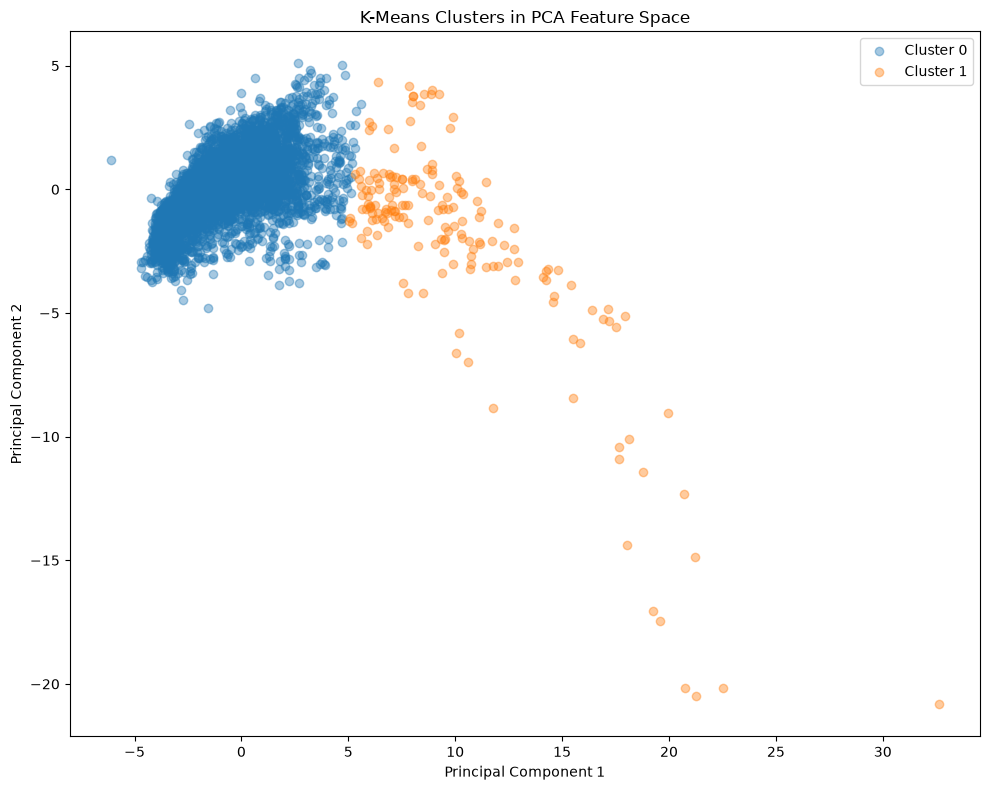

In [29]:
plt.figure(figsize=(10, 8))

for cluster_id in sorted(
    pca_cluster_df["cluster"].unique()
):

    cluster_data = pca_cluster_df[
        pca_cluster_df["cluster"] == cluster_id
    ]

    plt.scatter(
        cluster_data["PC1"],
        cluster_data["PC2"],
        alpha=0.4,
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.title(
    "K-Means Clusters in PCA Feature Space"
)

plt.legend()
plt.tight_layout()
plt.show()

In [30]:
cluster_disease_table = pd.crosstab(
    train_clustered_df["cluster"],
    train_clustered_df["diagnosis"]
)

display(cluster_disease_table)

diagnosis,Asthma,Bronchiectasis,Bronchiolitis,COPD,Healthy,LRTI,Pneumonia,URTI
cluster,,,,,,,,
0,6,65,74,3195,146,32,285,163
1,0,25,0,142,1,0,0,8


In [32]:
cluster_sound_table = pd.crosstab(
    train_clustered_df["cluster"],
    train_clustered_df["sound_label"]
)

display(cluster_sound_table)

sound_label,Both,Crackles,Normal,Wheezes
cluster,,,,
0,357,1195,1943,471
1,6,20,120,30


In [33]:
cluster_sound_proportion = pd.crosstab(
    train_clustered_df["cluster"],
    train_clustered_df["sound_label"],
    normalize="index"
)

display(
    cluster_sound_proportion.round(3)
)

sound_label,Both,Crackles,Normal,Wheezes
cluster,,,,
0,0.090,0.301,0.490,0.119
1,0.034,0.114,0.682,0.170


In [34]:
ari_disease = adjusted_rand_score(
    train_clustered_df["diagnosis"],
    train_clustered_df["cluster"]
)

ari_sound = adjusted_rand_score(
    train_clustered_df["sound_label"],
    train_clustered_df["cluster"]
)

print(
    "ARI vs disease:",
    round(ari_disease, 4)
)

print(
    "ARI vs sound label:",
    round(ari_sound, 4)
)

ARI vs disease: 0.0014
ARI vs sound label: -0.0093


In [35]:
nmi_disease = normalized_mutual_info_score(
    train_clustered_df["diagnosis"],
    train_clustered_df["cluster"]
)

nmi_sound = normalized_mutual_info_score(
    train_clustered_df["sound_label"],
    train_clustered_df["cluster"]
)

print(
    "NMI vs disease:",
    round(nmi_disease, 4)
)

print(
    "NMI vs sound label:",
    round(nmi_sound, 4)
)

NMI vs disease: 0.0242
NMI vs sound label: 0.0087


## Clustering Interpretation

The clustering analysis showed that K-Means with K=2 produced the highest
silhouette score among the tested cluster counts. However, the resulting
clusters showed almost no agreement with the known disease or respiratory
sound labels.

The Adjusted Rand Index (ARI) between the K-Means clusters and disease labels
was 0.0014, while the Normalized Mutual Information (NMI) was 0.0242.
For sound labels, the ARI was -0.0093 and the NMI was 0.0087.

These values are close to zero and indicate that the discovered unsupervised
clusters do not correspond strongly to the known disease or sound categories.

Therefore, the feature space contains some natural structure, as indicated by
the silhouette score, but this structure is not aligned with the target
classification labels. This may be influenced by the high-dimensional
acoustic feature representation, the use of cycle-level samples, and the fact
that disease is a patient-level attribute.

This result does not mean that the features are unsuitable for supervised
classification. Instead, it demonstrates that natural clusters discovered
through unsupervised learning do not necessarily correspond to the target
disease classes.

The clustering analysis is therefore retained as a genuine Data Mining
component of the project rather than being treated as a supervised
classification result.